In [1]:
import numpy as np
import matplotlib.pyplot as plt

dt = 0.004                 # intervalo de muestreo: 4 ms
n  = 501                   # número de muestras
t  = np.arange(n) * dt     # eje de tiempo en segundos

print("tipo  :", type(t))
print("shape :", t.shape)
print("dtype :", t.dtype)
print("primeros 5:", t[:5])
print("último    :", t[-1], "s")

tipo  : <class 'numpy.ndarray'>
shape : (501,)
dtype : float64
primeros 5: [0.    0.004 0.008 0.012 0.016]
último    : 2.0 s


In [2]:
r = np.zeros(n)            # traza sin reflectores: 501 ceros

reflectores = [
    ("Base Terciario", 0.620,  0.18),
    ("T2 Mirador",     0.980, -0.12),
    ("K2 Gacheta",     1.340,  0.22),
]

for nombre, tiempo, rc in reflectores:
    i = int(round(tiempo / dt))
    r[i] = rc
    print(f"{nombre:16s} t={tiempo:.3f} s  ->  muestra {i:3d}   rc={rc:+.2f}")

print()
print("shape de r      :", r.shape)
print("muestras no nulas:", np.flatnonzero(r))
print("suma de r       :", r.sum())

Base Terciario   t=0.620 s  ->  muestra 155   rc=+0.18
T2 Mirador       t=0.980 s  ->  muestra 245   rc=-0.12
K2 Gacheta       t=1.340 s  ->  muestra 335   rc=+0.22

shape de r      : (501,)
muestras no nulas: [155 245 335]
suma de r       : 0.28


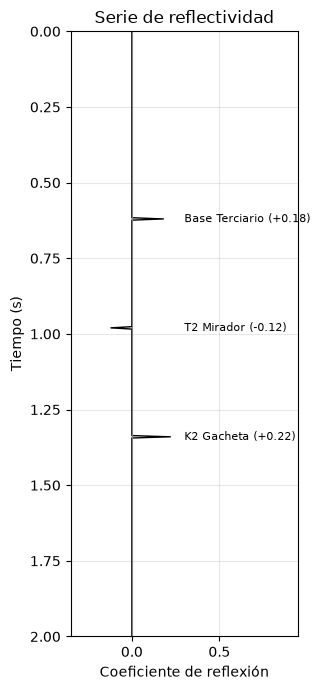

In [3]:
fig, ax = plt.subplots(figsize=(3.2, 7))

ax.plot(r, t, color="black", linewidth=1)
ax.axvline(0, color="gray", linewidth=0.8)

for nombre, tiempo, rc in reflectores:
    ax.text(0.30, tiempo, f"{nombre} ({rc:+.2f})", va="center", fontsize=8)

ax.set_xlabel("Coeficiente de reflexión")
ax.set_ylabel("Tiempo (s)")
ax.set_title("Serie de reflectividad")
ax.set_xlim(-0.35, 0.95)
ax.set_ylim(t[0], t[-1])
ax.invert_yaxis()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

muestras de la ondícula: (65,)
máximo en el índice    : 32 de 65
tiempo de ese índice   : 0.0 s


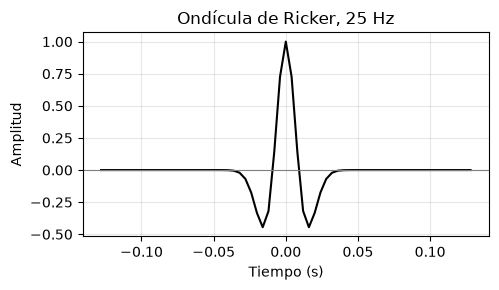

In [4]:
def ricker(f, dt, longitud=0.256):
    """Ondícula de Ricker de frecuencia dominante f (Hz)."""
    n_w = int(longitud / dt)
    if n_w % 2 == 0:
        n_w += 1                        # longitud impar: la ondícula queda centrada
    tw  = (np.arange(n_w) - n_w // 2) * dt
    arg = (np.pi * f * tw) ** 2
    w   = (1 - 2 * arg) * np.exp(-arg)
    return tw, w


tw, w = ricker(f=25, dt=dt)

print("muestras de la ondícula:", w.shape)
print("máximo en el índice    :", np.argmax(w), "de", len(w))
print("tiempo de ese índice   :", tw[np.argmax(w)], "s")

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(tw, w, color="black")
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Amplitud")
ax.set_title("Ondícula de Ricker, 25 Hz")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

r: (501,)   w: (65,)   s: (501,)
amplitud máxima: 0.22


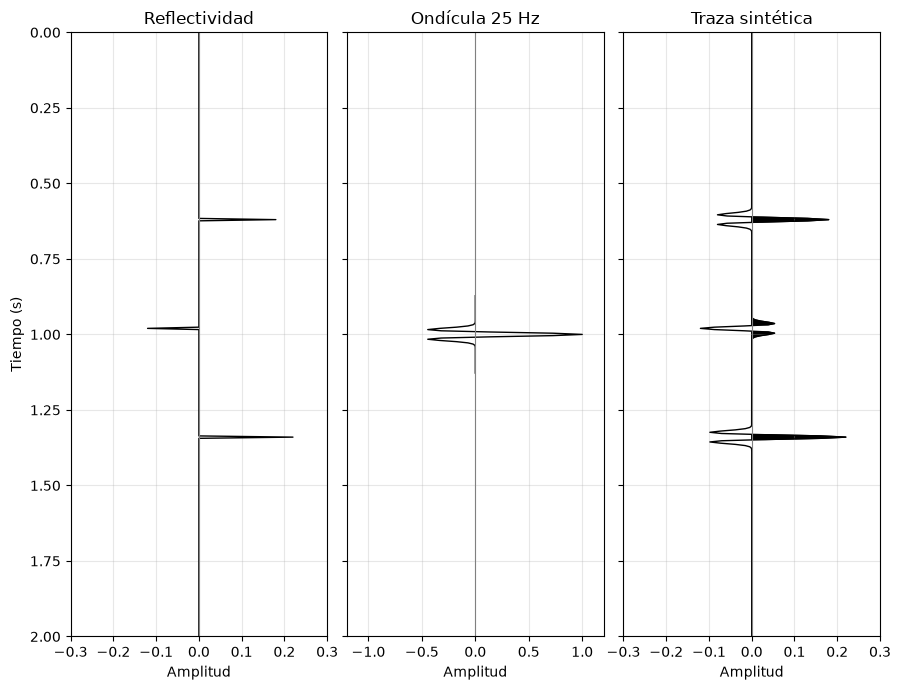

In [5]:
s = np.convolve(r, w, mode="same")

print("r:", r.shape, "  w:", w.shape, "  s:", s.shape)
print("amplitud máxima:", np.abs(s).max().round(4))

fig, axes = plt.subplots(1, 3, figsize=(9, 7), sharey=True)

axes[0].plot(r, t, color="black", lw=1)
axes[0].set_title("Reflectividad")
axes[0].set_xlim(-0.3, 0.3)

axes[1].plot(w, tw + 1.0, color="black", lw=1)
axes[1].set_title("Ondícula 25 Hz")
axes[1].set_xlim(-1.2, 1.2)

axes[2].plot(s, t, color="black", lw=1)
axes[2].fill_betweenx(t, 0, s, where=(s > 0), color="black")
axes[2].set_title("Traza sintética")
axes[2].set_xlim(-0.3, 0.3)

for ax in axes:
    ax.axvline(0, color="gray", lw=0.8)
    ax.set_xlabel("Amplitud")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Tiempo (s)")
axes[0].set_ylim(t[0], t[-1])
axes[0].invert_yaxis()

plt.tight_layout()
plt.show()

In [6]:
n_tr = 120                      # número de trazas
dx   = 25.0                     # espaciamiento entre trazas (m)
x    = np.arange(n_tr) * dx     # distancia a lo largo de la línea (m)

def geometria(t0, pendiente, cierre, x0=1500.0, ancho=700.0):
    """Horizonte buzante con un cierre anticlinal centrado en x0."""
    return t0 + pendiente * x - cierre * np.exp(-((x - x0) / ancho) ** 2)

horizontes = {
    "Base Terciario": (geometria(0.620, 8.0e-5, 0.030),  0.18),
    "T2 Mirador":     (geometria(0.980, 1.1e-4, 0.045), -0.12),
    "K2 Gacheta":     (geometria(1.340, 1.4e-4, 0.055),  0.22),
}

R = np.zeros((n_tr, n))         # modelo de reflectividad: 120 trazas x 501 muestras

for nombre, (tiempos, rc) in horizontes.items():
    indices = np.round(tiempos / dt).astype(int)
    R[np.arange(n_tr), indices] = rc
    print(f"{nombre:16s}  t: {tiempos.min():.3f} a {tiempos.max():.3f} s   rc={rc:+.2f}")

print()
print("shape de R:", R.shape, " -> (trazas, muestras)")
print("longitud de la línea:", x[-1], "m")

Base Terciario    t: 0.620 a 0.858 s   rc=+0.18
T2 Mirador        t: 0.980 a 1.307 s   rc=-0.12
K2 Gacheta        t: 1.339 a 1.756 s   rc=+0.22

shape de R: (120, 501)  -> (trazas, muestras)
longitud de la línea: 2975.0 m


shape de S: (120, 501)
amplitud máxima: 0.22


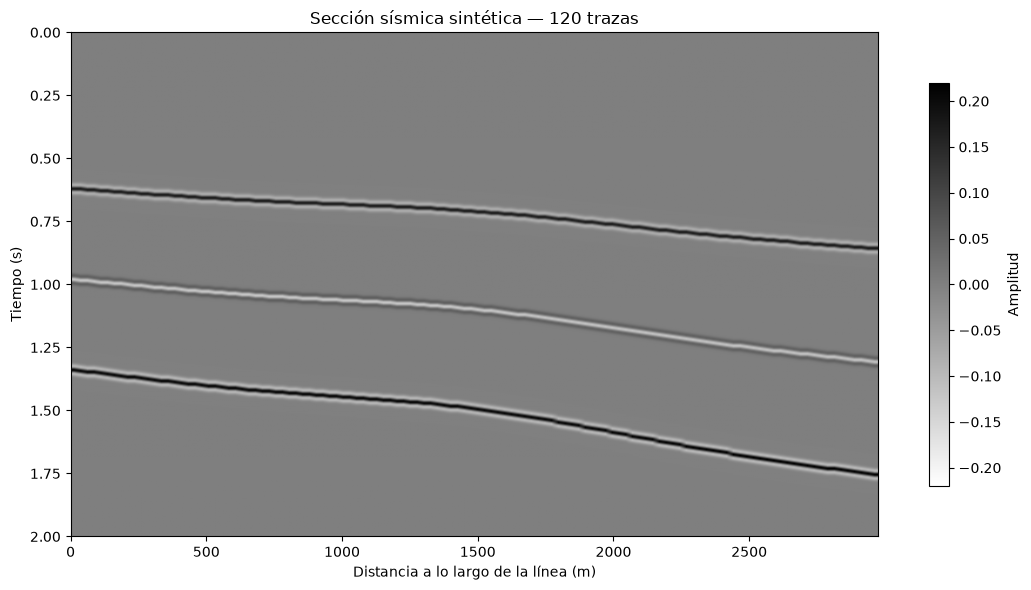

In [7]:
S = np.zeros_like(R)
for i in range(n_tr):
    S[i] = np.convolve(R[i], w, mode="same")

print("shape de S:", S.shape)
print("amplitud máxima:", np.abs(S).max().round(4))

lim = np.abs(S).max()

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(S.T,
               cmap="gray_r",
               vmin=-lim, vmax=lim,
               extent=[x[0], x[-1], t[-1], t[0]],
               aspect="auto",
               interpolation="bilinear")

ax.set_xlabel("Distancia a lo largo de la línea (m)")
ax.set_ylabel("Tiempo (s)")
ax.set_title("Sección sísmica sintética — 120 trazas")
fig.colorbar(im, ax=ax, label="Amplitud", shrink=0.8)
plt.tight_layout()
plt.show()

desplazamiento mínimo: -52 muestras
desplazamiento máximo: 30 muestras


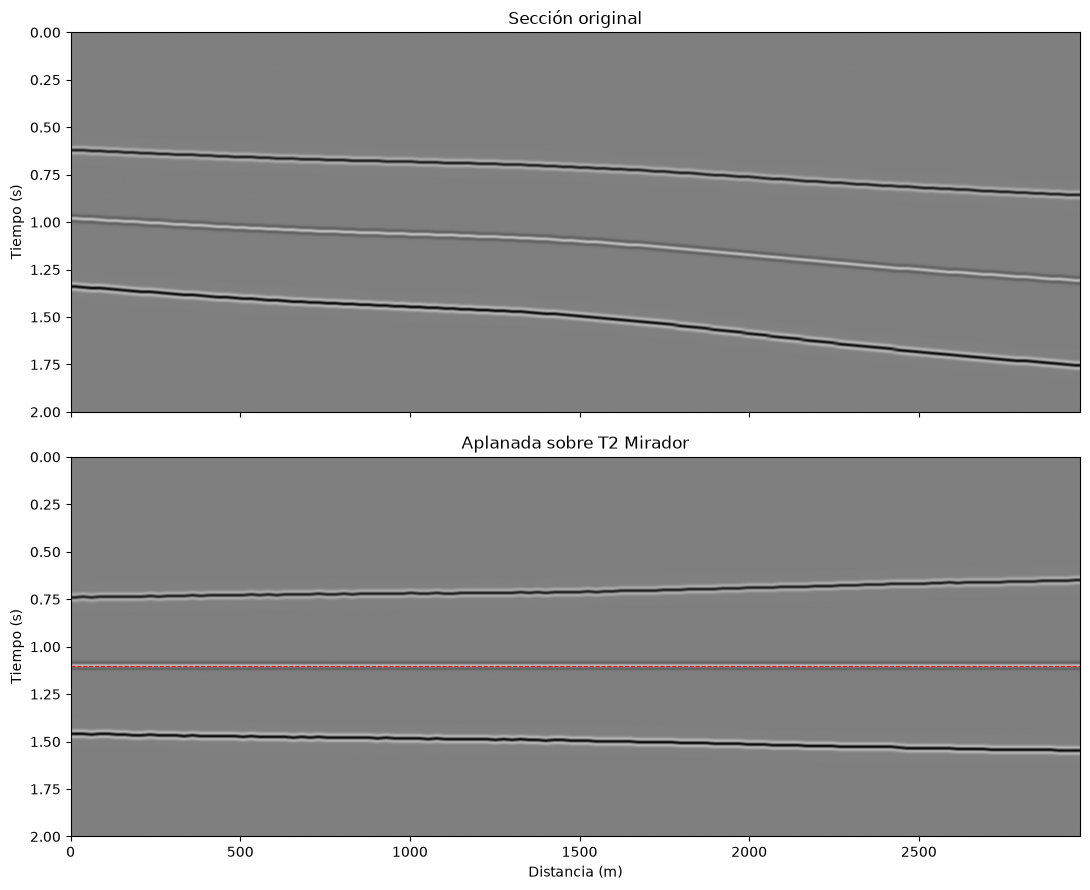

In [8]:
i_ref = np.round(horizontes["T2 Mirador"][0] / dt).astype(int)
i_obj = int(round(1.100 / dt))

S_plano = np.zeros_like(S)
for i in range(n_tr):
    S_plano[i] = np.roll(S[i], i_obj - i_ref[i])

print("desplazamiento mínimo:", (i_obj - i_ref).min(), "muestras")
print("desplazamiento máximo:", (i_obj - i_ref).max(), "muestras")

fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

for ax, dato, titulo in [(axes[0], S, "Sección original"),
                         (axes[1], S_plano, "Aplanada sobre T2 Mirador")]:
    ax.imshow(dato.T, cmap="gray_r", vmin=-lim, vmax=lim,
              extent=[x[0], x[-1], t[-1], t[0]],
              aspect="auto", interpolation="bilinear")
    ax.set_title(titulo)
    ax.set_ylabel("Tiempo (s)")

axes[1].axhline(1.100, color="red", lw=0.8, ls="--")
axes[1].set_xlabel("Distancia (m)")
plt.tight_layout()
plt.show()

In [13]:
n_il, n_xl = 80, 100
d_il = d_xl = 25.0

X = np.arange(n_il) * d_il      # dirección inline (m)
Y = np.arange(n_xl) * d_xl      # dirección crossline (m)
XX, YY = np.meshgrid(X, Y, indexing="ij")

print("X :", X.shape, "  Y :", Y.shape)
print("XX:", XX.shape, "  YY:", YY.shape)


def superficie(t0, px, py, cierre, x0=1000.0, y0=1250.0, ancho=600.0):
    """Horizonte buzante con un domo centrado en (x0, y0)."""
    d2 = ((XX - x0) / ancho) ** 2 + ((YY - y0) / ancho) ** 2
    return t0 + px * XX + py * YY - cierre * np.exp(-d2)


horizontes3d = {
    "Base Terciario": (superficie(0.620, 6.0e-5, 4.0e-5, 0.035),  0.18),
    "T2 Mirador":     (superficie(0.980, 6.0e-5, 4.0e-5, 0.100), -0.12),
    "K2 Gacheta":     (superficie(1.340, 6.0e-5, 4.0e-5, 0.060),  0.22),
}

Vr = np.zeros((n_il, n_xl, n))
ii, jj = np.indices((n_il, n_xl))

for nombre, (sup, rc) in horizontes3d.items():
    idx = np.round(sup / dt).astype(int)
    Vr[ii, jj, idx] = rc
    print(f"{nombre:16s} t: {sup.min():.3f} a {sup.max():.3f} s   shape sup: {sup.shape}")

print()
print("shape de Vr:", Vr.shape, " -> (inline, crossline, muestra)")
print("tamaño en memoria:", Vr.nbytes / 1e6, "MB")

X : (80,)   Y : (100,)
XX: (80, 100)   YY: (80, 100)
Base Terciario   t: 0.620 a 0.837 s   shape sup: (80, 100)
T2 Mirador       t: 0.980 a 1.197 s   shape sup: (80, 100)
K2 Gacheta       t: 1.340 a 1.557 s   shape sup: (80, 100)

shape de Vr: (80, 100, 501)  -> (inline, crossline, muestra)
tamaño en memoria: 32.064 MB


shape de V: (80, 100, 501)
amplitud máxima: 0.22

inline 40      -> (100, 501)
crossline 50   -> (80, 501)
time slice 1.0 s -> (80, 100)  (muestra 250)


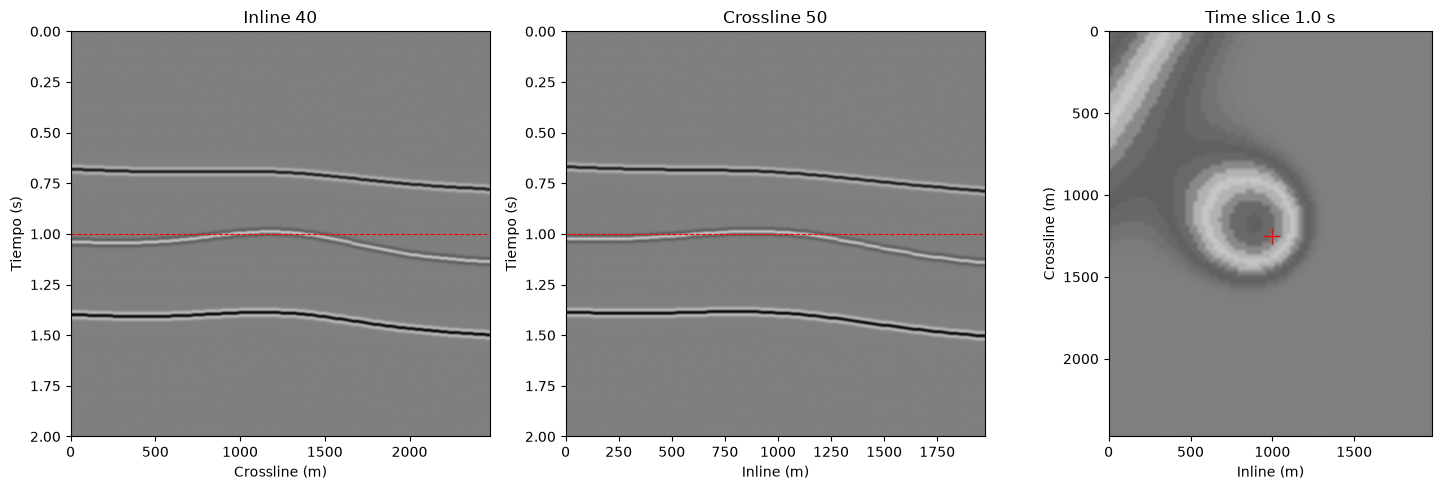

In [14]:
from scipy.signal import fftconvolve

V = fftconvolve(Vr, w[np.newaxis, np.newaxis, :], mode="same", axes=2)

print("shape de V:", V.shape)
print("amplitud máxima:", np.abs(V).max().round(4))

il_sel, xl_sel, t_sel = 40, 50, 1.000
it_sel = int(round(t_sel / dt))

inline    = V[il_sel, :, :]      # fijo la inline  -> (crossline, muestra)
crossline = V[:, xl_sel, :]      # fijo la crossline -> (inline, muestra)
timeslice = V[:, :, it_sel]      # fijo el tiempo  -> (inline, crossline)

print(f"\ninline {il_sel}      -> {inline.shape}")
print(f"crossline {xl_sel}   -> {crossline.shape}")
print(f"time slice {t_sel} s -> {timeslice.shape}  (muestra {it_sel})")

lim3 = np.abs(V).max()
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(inline.T, cmap="gray_r", vmin=-lim3, vmax=lim3,
               extent=[Y[0], Y[-1], t[-1], t[0]], aspect="auto",
               interpolation="bilinear")
axes[0].set_title(f"Inline {il_sel}")
axes[0].set_xlabel("Crossline (m)"); axes[0].set_ylabel("Tiempo (s)")
axes[0].axhline(t_sel, color="red", lw=0.8, ls="--")

axes[1].imshow(crossline.T, cmap="gray_r", vmin=-lim3, vmax=lim3,
               extent=[X[0], X[-1], t[-1], t[0]], aspect="auto",
               interpolation="bilinear")
axes[1].set_title(f"Crossline {xl_sel}")
axes[1].set_xlabel("Inline (m)"); axes[1].set_ylabel("Tiempo (s)")
axes[1].axhline(t_sel, color="red", lw=0.8, ls="--")

axes[2].imshow(timeslice.T, cmap="gray_r", vmin=-lim3, vmax=lim3,
               extent=[X[0], X[-1], Y[-1], Y[0]], aspect="equal",
               interpolation="bilinear")
axes[2].set_title(f"Time slice {t_sel} s")
axes[2].set_xlabel("Inline (m)"); axes[2].set_ylabel("Crossline (m)")
axes[2].plot(X[il_sel], Y[xl_sel], "r+", markersize=12)

plt.tight_layout()
plt.show()